# Imports

In [108]:
!pip install numpy pandas matplotlib plotly scipy scikit-image scikit-learn torch torchvision kagglehub
!pip install nbformat

In [109]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
import torch.nn as nn
import torch.nn.functional as F
import kagglehub
import os

In [110]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
pmem = True if device == "cuda" else False
print(device)

mps


In [111]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    ])
images = torchvision.datasets.ImageFolder("coil-20-proc", transform=transform)


train_size = int(0.8 * len(images))
valid_size = len(images) - train_size

images_train, images_valid = torch.utils.data.random_split(images, [train_size, valid_size])
print(images.classes)

train_images = DataLoader(images_train, batch_size=32, shuffle=True, pin_memory=pmem)
valid_images = DataLoader(images_valid, batch_size=32, shuffle=False,pin_memory=pmem)

['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20']


In [112]:
print(len(images_train))
len(images_valid)

1152


288

In [113]:
def label_string(label_int):
    match label_int:
        case 0:
            return "duck"
        case 1:
            return "block toy"
        case 2:
            return "toy racecar"
        case 3:
            return "waving cat"
        case 4:
            return "anacin box"
        case 5:
            return "toy convertible"
        case 6:
            return "block toy 2"
        case 7:
            return "baby powder"
        case 8:
            return "tylenol"
        case 9:
            return "vaseline"
        case 10:
            return "block toy (semicircle)"
        case 11:
            return "cup"
        case 12:
            return "piggy bank"
        case 13:
            return "valve"
        case 14:
            return "bucket"
        case 15:
            return "conditioner bottle"
        case 16:
            return "pot"
        case 17:
            return "teacup"
        case 18:
            return "toy convertible (lame)"
        case 19:
            return "cream cheese tub"
        case _:
            return "none of the above"

In [114]:
train_images

In [115]:
model = nn.Sequential()
model.add_module(
    'conv1',
    nn.Conv2d(
        in_channels=1,out_channels=32,
        kernel_size=5,padding=2
    )
)
model.add_module('relu1',nn.ReLU())
model.add_module('pool1',nn.MaxPool2d(kernel_size=2))

model.add_module(
    'conv2',
    nn.Conv2d(
        in_channels=32, out_channels=64,
        kernel_size=5,padding=2
    )
)
model.add_module('relu2',nn.ReLU())
model.add_module('pool2',nn.MaxPool2d(kernel_size=2))

model.add_module('avgpool',nn.AdaptiveAvgPool2d((4,4)))

model.add_module('flatten',nn.Flatten())

x = torch.ones((4,1,128,128))
dims = model(x).shape

model.add_module('fc1',nn.Linear(dims[1], 512))
model.add_module('relu3', nn.ReLU())
model.add_module('dropout',nn.Dropout(p=0.5))
model.add_module('fc2',nn.Linear(512,20))
model.to(device)

Sequential(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (avgpool): AdaptiveAvgPool2d(output_size=(4, 4))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1024, out_features=512, bias=True)
  (relu3): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=20, bias=True)
)

In [121]:
num_epochs = 15

loss_history_train = np.zeros(num_epochs)
accuracy_history_train = np.zeros(num_epochs)
loss_history_valid = np.zeros(num_epochs)
accuracy_history_valid = np.zeros(num_epochs)

In [122]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [123]:
torch.manual_seed(540)

noise_std = 0.00

for epoch in range(num_epochs):
    model.train()
    for x_batch, y_batch in train_images:
        # test adding noise:
        noise = torch.randn_like(x_batch)*noise_std
        x_batch = x_batch + noise

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
        loss_history_train[epoch] += loss.item()*y_batch.size(0)
        accuracy_history_train[epoch] += is_correct.sum()
    
    model.eval()

    loss_history_train[epoch] /= len(train_images.dataset)
    accuracy_history_train[epoch] /= len(train_images.dataset)

    with torch.no_grad():
        for x_batch, y_batch in valid_images:

            noise = torch.randn_like(x_batch)*noise_std
            x_batch += noise

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(x_batch)
            loss = loss_fn(pred, y_batch)
            is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
            loss_history_valid[epoch] += loss.item()*y_batch.size(0)
            accuracy_history_valid[epoch] += is_correct.sum()
    
    loss_history_valid[epoch] /= len(valid_images.dataset)
    accuracy_history_valid[epoch] /= len(valid_images.dataset)
    
    print(f"Epoch {epoch} accuracy: {accuracy_history_train[epoch]:.4f} "
          f"val_accuracy: {accuracy_history_valid[epoch]}")

#torch.save(model.state_dict(), "prebuilts/coil20_{:.3f}.pth".format(noise_std))


Epoch 0 accuracy: 0.1832 val_accuracy: 0.5902777777777778
Epoch 1 accuracy: 0.5556 val_accuracy: 0.6527777777777778
Epoch 2 accuracy: 0.7118 val_accuracy: 0.8680555555555556
Epoch 3 accuracy: 0.8012 val_accuracy: 0.8611111111111112
Epoch 4 accuracy: 0.8655 val_accuracy: 0.9270833333333334
Epoch 5 accuracy: 0.9054 val_accuracy: 0.9375
Epoch 6 accuracy: 0.9236 val_accuracy: 0.96875
Epoch 7 accuracy: 0.9227 val_accuracy: 0.9548611111111112
Epoch 8 accuracy: 0.9497 val_accuracy: 0.9513888888888888
Epoch 9 accuracy: 0.9609 val_accuracy: 0.9895833333333334
Epoch 10 accuracy: 0.9688 val_accuracy: 0.9756944444444444
Epoch 11 accuracy: 0.9774 val_accuracy: 0.9895833333333334
Epoch 12 accuracy: 0.9714 val_accuracy: 0.9895833333333334
Epoch 13 accuracy: 0.9748 val_accuracy: 0.9756944444444444
Epoch 14 accuracy: 0.9800 val_accuracy: 0.9930555555555556


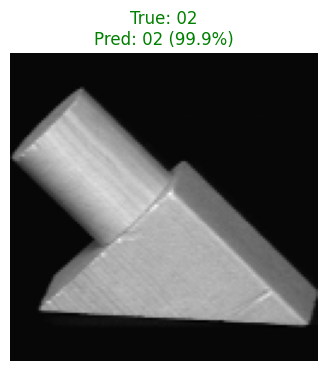

In [124]:
img_tensor, label = images[73]
input_tensor = img_tensor.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    logits = model(input_tensor)
    probs = F.softmax(logits, dim=1)
    confidence, pred_label = torch.max(probs,1)

    predicted_class = images.classes[pred_label.item()]
    true_class = images.classes[label]
    conf_score = confidence.item()

    plt.figure(figsize=(4,4))
    plt.imshow(img_tensor.permute(1,2,0),cmap='gray')
    title_color = 'green' if predicted_class == true_class else 'red'
    plt.title(f"True: {true_class}\nPred: {predicted_class} ({conf_score:.1%})", color=title_color)
    plt.axis('off')
    plt.show()

In [125]:
count_correct = 0
incorrect = []
for i in range(1440):
    img_tensor, label = images[i]
    input_tensor = img_tensor.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        probs = F.softmax(logits, dim=1)
        confidence, pred_label = torch.max(probs,1)

        predicted_class = images.classes[pred_label.item()]
        true_class = images.classes[label]
        conf_score = confidence.item()
        if predicted_class == true_class:
            count_correct += 1
        else:
            incorrect.append(i)


In [126]:
def display_image_tensor(img_tensor):
    plt.figure(figsize=(4,4))
    plt.imshow(img_tensor.permute(1,2,0), cmap='gray')
    plt.axis('off')
    plt.show()
    

In [127]:
count_correct

1438

In [128]:
count_correct/1440

0.9986111111111111

In [129]:
def attack(image_index, delta, n):
    # Attack
    #perturbed_image_disp = perturbed_image.cpu().detach()
    #display_image_tensor(perturbed_image_disp)
    image_tensor, label = images[image_index]
    start_image = image_tensor.unsqueeze(0).to(device)
    label = torch.Tensor([label]).to(device)
    start_image.requires_grad = True
    for i in range(n):

        start_image.requires_grad = True

        output = model(start_image)
        init_pred = output.max(1, keepdim=True)[1]

        loss = F.nll_loss(output, label.long())
        model.zero_grad()
        loss.backward()

        image_grad = start_image.grad.data
        #grad_sign = torch.sign(image_grad)
        perturbed_image = start_image + delta*image_grad
        #perturbed_image = start_image + delta*grad_sign
        perturbed_image = torch.clamp(perturbed_image,0,1)

        output_pert = model(perturbed_image)

        pert_pred = output_pert.max(1,keepdim=True)[1]
        probs_init = F.softmax(output, dim=1)
        probs_pert = F.softmax(output_pert, dim=1)

        confidence_init, pred_label_init = torch.max(probs_init,1)
        conf_init_float = float(confidence_init.detach())
        pred_init_int = int(pred_label_init.detach())

        confidence_pert, pred_label_pert = torch.max(probs_pert,1)
        conf_pert_float = float(confidence_pert.detach())
        pred_pert_int = int(pred_label_pert.detach())
        #print("init_pred: {}, with confidence: {:f}".format(label_string(pred_init_int), conf_init_float))
        print("pred: {}, with confidence: {:f}".format(label_string(pred_pert_int), conf_pert_float))
        if init_pred != pert_pred:
            break
        start_image = perturbed_image.detach()

    return_image = start_image.squeeze(0).cpu().detach()
    diff_image = torch.abs(return_image - image_tensor)

    return return_image, diff_image

In [117]:
def attack_sign(image_index, eps, n):
    # Attack
    #perturbed_image_disp = perturbed_image.cpu().detach()
    #display_image_tensor(perturbed_image_disp)
    image_tensor, label = images[image_index]
    start_image = image_tensor.unsqueeze(0).to(device)
    label = torch.Tensor([label]).to(device)
    start_image.requires_grad = True
    for i in range(n):

        start_image.requires_grad = True

        output = model(start_image)
        init_pred = output.max(1, keepdim=True)[1]

        loss = F.nll_loss(output, label.long())
        model.zero_grad()
        loss.backward()

        image_grad = start_image.grad.data
        grad_sign = torch.sign(image_grad)
        #perturbed_image = start_image + delta*image_grad
        perturbed_image = start_image + eps*grad_sign
        perturbed_image = torch.clamp(perturbed_image,0,1)

        output_pert = model(perturbed_image)

        pert_pred = output_pert.max(1,keepdim=True)[1]
        probs_init = F.softmax(output, dim=1)
        probs_pert = F.softmax(output_pert, dim=1)

        confidence_init, pred_label_init = torch.max(probs_init,1)
        conf_init_float = float(confidence_init.detach())
        pred_init_int = int(pred_label_init.detach())

        confidence_pert, pred_label_pert = torch.max(probs_pert,1)
        conf_pert_float = float(confidence_pert.detach())
        pred_pert_int = int(pred_label_pert.detach())
        #print("init_pred: {}, with confidence: {:f}".format(label_string(pred_init_int), conf_init_float))
        print("pred: {}, with confidence: {:f}".format(label_string(pred_pert_int), conf_pert_float))
        if init_pred != pert_pred:
            start_image = perturbed_image.detach()
            break
        start_image = perturbed_image.detach()

    return_image = start_image.squeeze(0).cpu().detach()
    diff_image = torch.abs(return_image - image_tensor)

    return return_image, diff_image


pred: block toy, with confidence: 0.996986
pred: block toy, with confidence: 0.993276
pred: block toy, with confidence: 0.984912
pred: block toy, with confidence: 0.965540
pred: block toy, with confidence: 0.927235
pred: block toy, with confidence: 0.856954
pred: block toy, with confidence: 0.741426
pred: block toy, with confidence: 0.581701
pred: block toy 2, with confidence: 0.421879
tensor(6.8383)


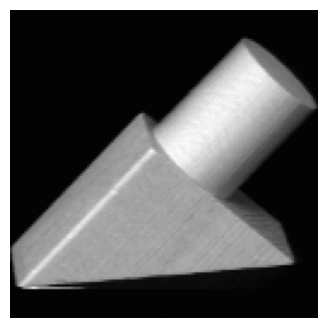

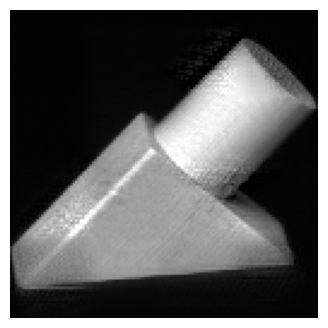

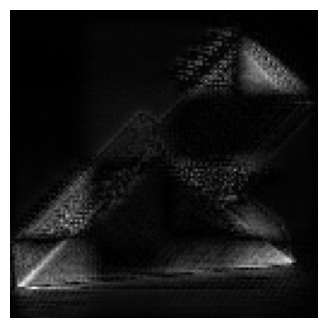

In [130]:
image_num = 100
image_attack, diff = attack(image_num, 1,200)
print(torch.norm(diff))
image_original, _ = images[image_num]
display_image_tensor(image_original)
display_image_tensor(image_attack)
display_image_tensor(diff)

pred: duck, with confidence: 0.998215
pred: duck, with confidence: 0.994148
pred: duck, with confidence: 0.982099
pred: duck, with confidence: 0.935603
pred: duck, with confidence: 0.782093
pred: anacin box, with confidence: 0.474644
tensor(6.0046)


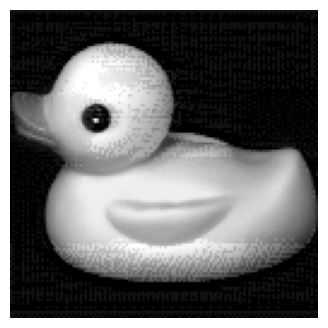

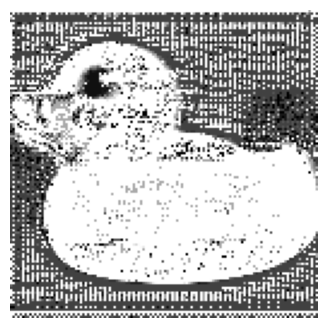

In [131]:
image_attack_sign, diff_sign = attack_sign(0,0.01,200)
print(torch.norm(diff_sign))
display_image_tensor(image_attack_sign)
display_image_tensor(diff_sign)

In [77]:
ducks = torchvision.datasets.ImageFolder("ducks", transform=transform)

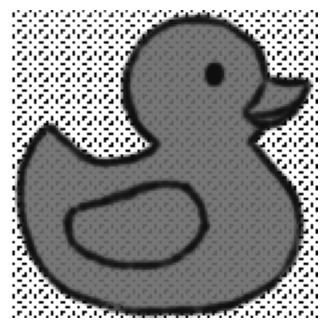

In [78]:
my_duck,_ = ducks[5]
display_image_tensor(my_duck)
my_duck = my_duck.unsqueeze(0).to(device)
my_output = model(my_duck)
probs = F.softmax(my_output, dim=1)
confidence, pred_label = torch.max(probs,1)

In [79]:
float(confidence.detach())

0.9247429966926575

In [80]:
pred_label

tensor([8], device='mps:0')

In [138]:
device

'mps'

In [139]:
results = []
for i in range(101):
    results_i = []
    model_path = "prebuilts/coil20_0.{:03d}.pth".format(i)
    print(model_path)
    model.load_state_dict(torch.load(model_path, weights_only=True,map_location=torch.device(device)))
    model.eval()
    for j in range(1440):
        image,diff = attack(j,1,200)
        #print(torch.norm(diff))
        print((i,j))
        results_i.append(torch.norm(diff))
    results.append(results_i)
    torch.mps.empty_cache()

prebuilts/coil20_0.000.pth
pred: duck, with confidence: 0.999999
pred: duck, with confidence: 0.999915
pred: duck, with confidence: 0.997509
pred: waving cat, with confidence: 0.949100
(0, 0)
pred: duck, with confidence: 0.999997
pred: duck, with confidence: 0.999547
pred: duck, with confidence: 0.933954
pred: block toy 2, with confidence: 0.681014
(0, 1)
pred: duck, with confidence: 0.999982
pred: duck, with confidence: 0.799401
pred: block toy 2, with confidence: 0.642926
(0, 2)
pred: duck, with confidence: 0.999857
pred: duck, with confidence: 0.765706
pred: block toy 2, with confidence: 0.998787
(0, 3)
pred: duck, with confidence: 0.999752
pred: duck, with confidence: 0.844313
pred: block toy 2, with confidence: 0.998928
(0, 4)
pred: duck, with confidence: 0.999510
pred: duck, with confidence: 0.720863
pred: block toy 2, with confidence: 0.999565
(0, 5)
pred: duck, with confidence: 0.998996
pred: duck, with confidence: 0.575125
pred: block toy 2, with confidence: 0.998356
(0, 6)
pr

KeyboardInterrupt: 

In [82]:
torch.save(model.state_dict(), "test.pth")